In [1]:
import os
HOME = os.getcwd()
print(HOME)

/kaggle/working


In [2]:
!pip install -i https://test.pypi.org/simple/ supervision==0.3.0
!pip install -q transformers
!pip install -q pytorch-lightning
!pip install -q roboflow
!pip install -q timm

Looking in indexes: https://test.pypi.org/simple/
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 29.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.8 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.4 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 79.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 37.8 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 90.9 MB/s

In [3]:
import torch
!nvcc --version
TORCH_VERSION = ".".join(torch.__version__.split(".")[:2])
CUDA_VERSION = torch.__version__.split("+")[-1]
print("torch: ", TORCH_VERSION, "; cuda: ", CUDA_VERSION)

import roboflow
import supervision
import transformers
import pytorch_lightning

print(
    "roboflow:", roboflow.__version__, 
    "; supervision:", supervision.__version__, 
    "; transformers:", transformers.__version__, 
    "; pytorch_lightning:", pytorch_lightning.__version__
)

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0
torch:  2.6 ; cuda:  cu124
roboflow: 1.2.0 ; supervision: 0.3.0 ; transformers: 4.51.3 ; pytorch_lightning: 2.5.1.post0


# Inference with pre-trained COCO model

## Download Data

In [4]:
%cd {HOME}
!wget https://media.roboflow.com/notebooks/examples/dog.jpeg

/kaggle/working
--2025-07-05 12:02:50--  https://media.roboflow.com/notebooks/examples/dog.jpeg
Resolving media.roboflow.com (media.roboflow.com)... 34.110.133.209
Connecting to media.roboflow.com (media.roboflow.com)|34.110.133.209|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 106055 (104K) [image/jpeg]
Saving to: ‘dog.jpeg’

dog.jpeg            100%[===================>] 103.57K  --.-KB/s    in 0.001s  

2025-07-05 12:02:50 (73.7 MB/s) - ‘dog.jpeg’ saved [106055/106055]



In [5]:
import os

IMAGE_NAME = "dog.jpeg"
IMAGE_PATH = os.path.join(HOME, IMAGE_NAME)

## Load Model

In [8]:
import warnings
warnings.filterwarnings("ignore")

In [9]:
import torch
from transformers import DetrForObjectDetection, DetrImageProcessor


# settings
DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
CHECKPOINT = 'facebook/detr-resnet-50'
CONFIDENCE_TRESHOLD = 0.5
IOU_TRESHOLD = 0.8

image_processor = DetrImageProcessor.from_pretrained(CHECKPOINT)
model = DetrForObjectDetection.from_pretrained(CHECKPOINT)
model.to(DEVICE)

Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing DetrForObjectDetection from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


DetrForObjectDetection(
  (model): DetrModel(
    (backbone): DetrConvModel(
      (conv_encoder): DetrConvEncoder(
        (model): FeatureListNet(
          (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
          (bn1): DetrFrozenBatchNorm2d()
          (act1): ReLU(inplace=True)
          (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
          (layer1): Sequential(
            (0): Bottleneck(
              (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
              (bn1): DetrFrozenBatchNorm2d()
              (act1): ReLU(inplace=True)
              (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
              (bn2): DetrFrozenBatchNorm2d()
              (drop_block): Identity()
              (act2): ReLU(inplace=True)
              (aa): Identity()
              (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      

## Inference

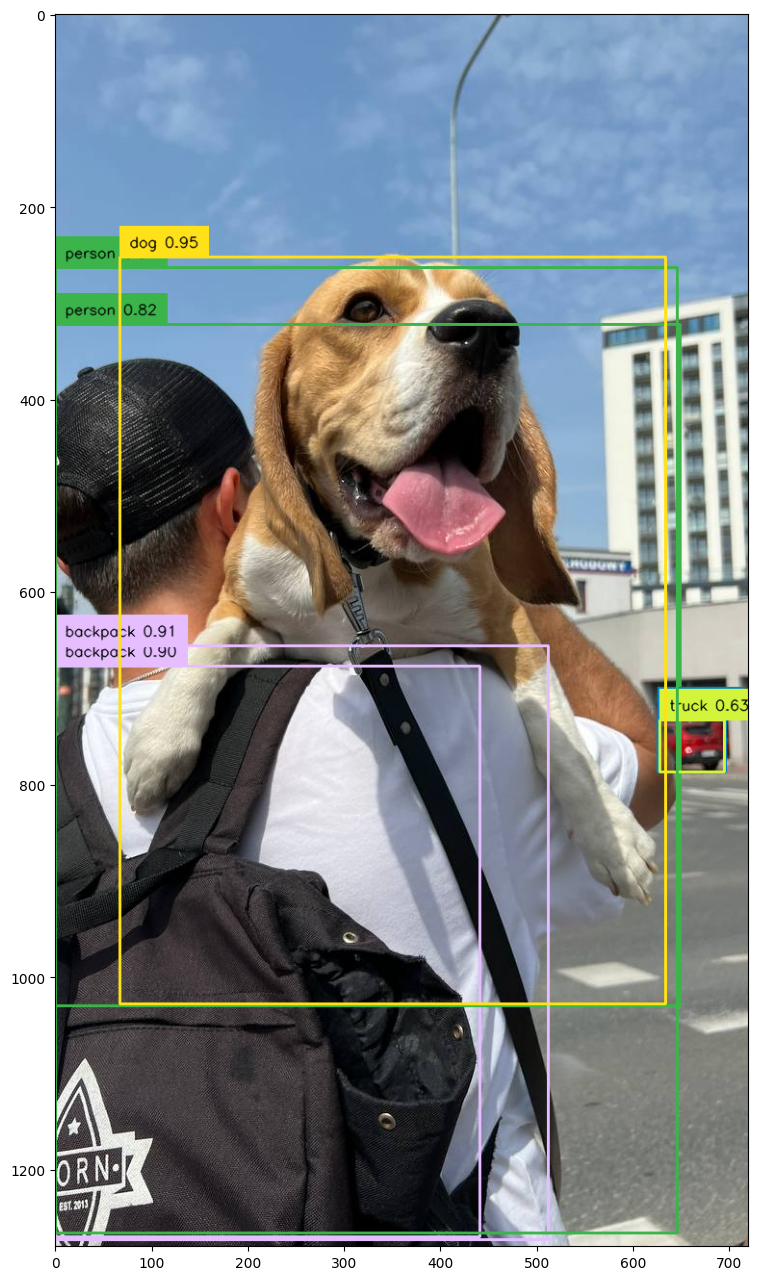

In [31]:
import cv2
import torch
import supervision as sv


with torch.no_grad():

    # load image and predict
    image = cv2.imread(IMAGE_PATH)
    inputs = image_processor(images=image, return_tensors='pt').to(DEVICE)
    outputs = model(**inputs) #cái gì đó khủng khiếp

    # post-process
    target_sizes = torch.tensor([image.shape[:2]]).to(DEVICE)
    results = image_processor.post_process_object_detection(
        outputs=outputs, 
        threshold=CONFIDENCE_TRESHOLD, 
        target_sizes=target_sizes
    )[0] #kết quả cuối cùng gọn gàng

# annotate
detections = sv.Detections.from_transformers(transformers_results=results)

labels = [
    f"{model.config.id2label[class_id]} {confidence:0.2f}" 
    for _, confidence, class_id, _ 
    in detections
]

box_annotator = sv.BoxAnnotator()
frame = box_annotator.annotate(scene=image, detections=detections, labels=labels)

%matplotlib inline  
sv.show_frame_in_notebook(frame, (16, 16))

In [32]:
detections

Detections(xyxy=array([[7.8022242e-01, 6.7780701e+02, 4.4147565e+02, 1.2702837e+03],
       [5.9800386e-01, 3.2239948e+02, 6.4956946e+02, 1.0304641e+03],
       [6.2620038e+02, 7.3113257e+02, 6.9654895e+02, 7.8738013e+02],
       [6.2825488e+02, 7.3335107e+02, 6.9528619e+02, 7.8788916e+02],
       [9.1049194e-01, 6.5678412e+02, 5.1246063e+02, 1.2730068e+03],
       [7.5290680e-01, 2.6315082e+02, 6.4631183e+02, 1.2667166e+03],
       [6.7614243e+01, 2.5231830e+02, 6.3454089e+02, 1.0284346e+03]],
      dtype=float32), class_id=array([27,  1,  3,  8, 27,  1, 18]), confidence=array([0.9030367 , 0.82044405, 0.88298553, 0.6265814 , 0.91429895,
       0.93654907, 0.9535258 ], dtype=float32), tracker_id=None)

## Infercence + NMS

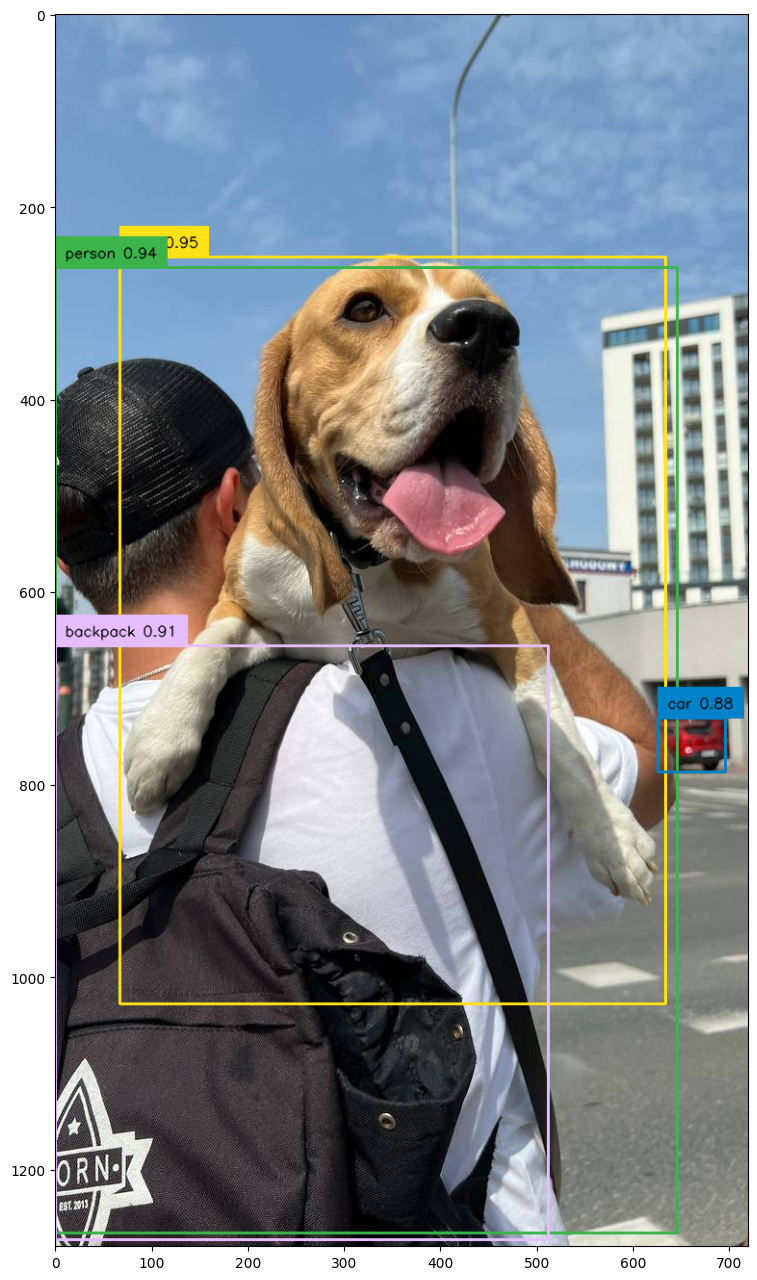

In [33]:
import cv2
import torch
import supervision as sv


with torch.no_grad():

    # load image and predict
    image = cv2.imread(IMAGE_PATH)
    inputs = image_processor(images=image, return_tensors='pt').to(DEVICE)
    outputs = model(**inputs)

    # post-process
    target_sizes = torch.tensor([image.shape[:2]]).to(DEVICE)
    results = image_processor.post_process_object_detection(
        outputs=outputs, 
        threshold=CONFIDENCE_TRESHOLD, 
        target_sizes=target_sizes
    )[0]

# annotate
detections = sv.Detections.from_transformers(transformers_results=results).with_nms(threshold=IOU_TRESHOLD)

labels = [
    f"{model.config.id2label[class_id]} {confidence:0.2f}" 
    for _, confidence, class_id, _ 
    in detections
]

box_annotator = sv.BoxAnnotator()
frame = box_annotator.annotate(scene=image, detections=detections, labels=labels)

%matplotlib inline  
sv.show_frame_in_notebook(frame, (16, 16))

In [35]:
inputs

{'pixel_values': tensor([[[[ 1.3413,  1.3413,  1.3413,  ...,  1.2899,  1.2728,  1.2728],
          [ 1.3242,  1.3242,  1.3242,  ...,  1.2899,  1.2899,  1.2728],
          [ 1.3242,  1.3242,  1.3242,  ...,  1.3070,  1.2899,  1.2899],
          ...,
          [ 1.3413,  1.6324,  1.8379,  ..., -0.2513, -0.2171, -0.3027],
          [ 1.2728,  1.6667,  1.6495,  ..., -0.3027, -0.3198, -0.3027],
          [ 1.4440,  1.2214,  1.6153,  ..., -0.3541, -0.2856, -0.0972]],

         [[ 0.7129,  0.7129,  0.7129,  ...,  0.7829,  0.7654,  0.7654],
          [ 0.6954,  0.6954,  0.6954,  ...,  0.7829,  0.7829,  0.7654],
          [ 0.6954,  0.6954,  0.6954,  ...,  0.8004,  0.7829,  0.7829],
          ...,
          [ 1.5357,  1.8333,  2.0434,  ...,  0.1352,  0.1527,  0.1176],
          [ 1.4657,  1.8683,  1.8508,  ...,  0.0826,  0.0476,  0.1001],
          [ 1.6408,  1.4132,  1.8158,  ...,  0.0301,  0.0826,  0.3102]],

         [[ 0.2871,  0.2871,  0.2871,  ...,  0.4439,  0.4265,  0.4265],
          [ 0

# Download custom dataset

In [23]:
from getpass import getpass

ROBOFLOW_API_KEY = getpass('Enter ROBOFLOW_API_KEY secret value: ')

Enter ROBOFLOW_API_KEY secret value:  ········


In [25]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="E6klOjeOgdAuTJyFXCpD")
project = rf.workspace("objectdetection-wdigz").project("football-players-detection-3zvbc-8txhe")
version = project.version(1)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...


In [26]:
dataset.location

'/kaggle/working/datasets/football-players-detection-1'

# Create COCO data loaders

In [48]:
import os
import torchvision


# settings
ANNOTATION_FILE_NAME = "_annotations.coco.json"
TRAIN_DIRECTORY = os.path.join(dataset.location, "train")
VAL_DIRECTORY = os.path.join(dataset.location, "valid")
TEST_DIRECTORY = os.path.join(dataset.location, "test")


class CocoDetection(torchvision.datasets.CocoDetection):
    def __init__(
        self, 
        image_directory_path: str, 
        image_processor, 
        train: bool = True
    ):
        annotation_file_path = os.path.join(image_directory_path, ANNOTATION_FILE_NAME)
        super(CocoDetection, self).__init__(image_directory_path, annotation_file_path)
        self.image_processor = image_processor

    def __getitem__(self, idx):
        images, annotations = super(CocoDetection, self).__getitem__(idx)        
        image_id = self.ids[idx]
        annotations = {'image_id': image_id, 'annotations': annotations}
        encoding = self.image_processor(images=images, annotations=annotations, return_tensors="pt") #dựa vào file annotation để đưa ra nhãn
        pixel_values = encoding["pixel_values"].squeeze()   #add batch size                           #như bounding box, class_id
        target = encoding["labels"][0]

        return pixel_values, target


TRAIN_DATASET = CocoDetection(
    image_directory_path=TRAIN_DIRECTORY, 
    image_processor=image_processor, 
    train=True)
VAL_DATASET = CocoDetection(
    image_directory_path=VAL_DIRECTORY, 
    image_processor=image_processor, 
    train=False)
TEST_DATASET = CocoDetection(
    image_directory_path=TEST_DIRECTORY, 
    image_processor=image_processor, 
    train=False)

print("Number of training examples:", len(TRAIN_DATASET))
print("Number of validation examples:", len(VAL_DATASET))
print("Number of test examples:", len(TEST_DATASET))

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Number of training examples: 612
Number of validation examples: 38
Number of test examples: 13


Image #189


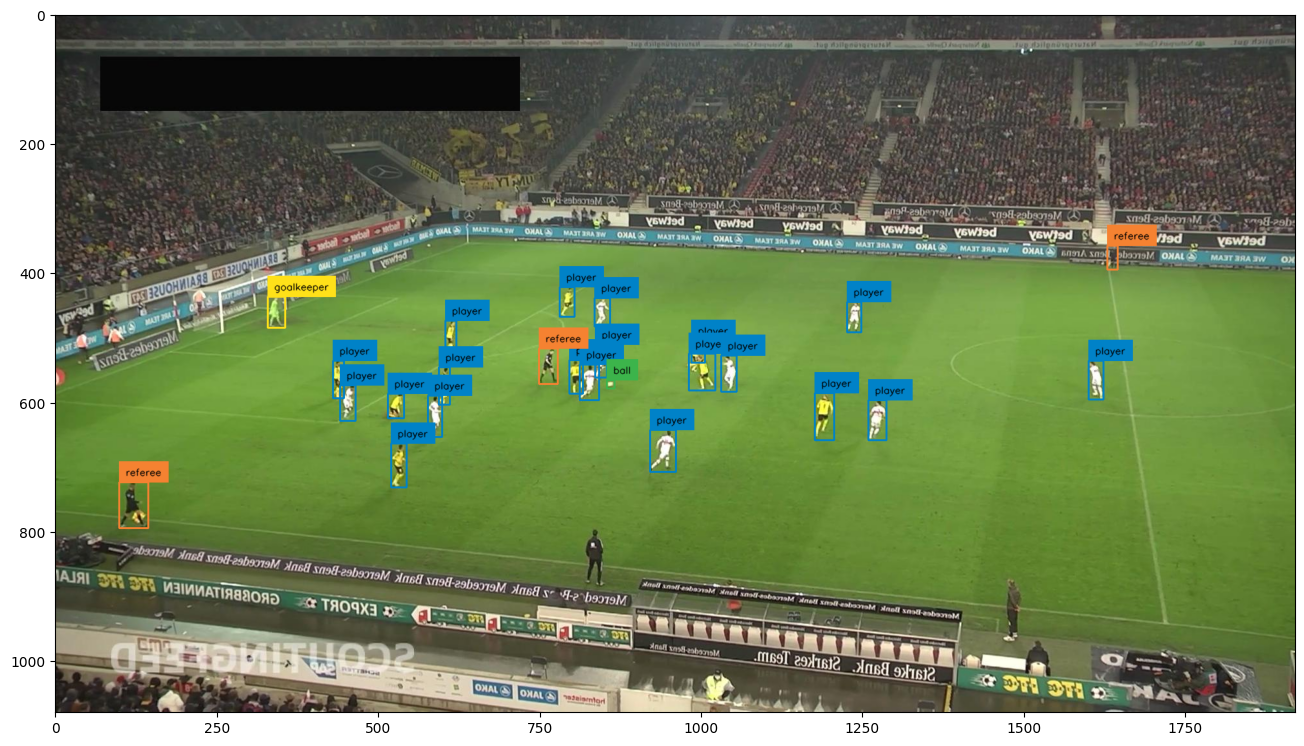

In [39]:
import random
import cv2
import numpy as np


# select random image
image_ids = TRAIN_DATASET.coco.getImgIds()
image_id = random.choice(image_ids)
print('Image #{}'.format(image_id))

# load image and annotatons 
image = TRAIN_DATASET.coco.loadImgs(image_id)[0]
annotations = TRAIN_DATASET.coco.imgToAnns[image_id]
image_path = os.path.join(TRAIN_DATASET.root, image['file_name'])
image = cv2.imread(image_path)

# annotate
detections = sv.Detections.from_coco_annotations(coco_annotation=annotations)

# we will use id2label function for training
categories = TRAIN_DATASET.coco.cats
id2label = {k: v['name'] for k,v in categories.items()}

labels = [
    f"{id2label[class_id]}" 
    for _, _, class_id, _ 
    in detections
]

box_annotator = sv.BoxAnnotator()
frame = box_annotator.annotate(scene=image, detections=detections, labels=labels)

%matplotlib inline  
sv.show_frame_in_notebook(image, (16, 16))

In [51]:
pixel_values, target = TRAIN_DATASET.__getitem__(0)
print('Pixel values: ', pixel_values)
print('Target: ', target)

Pixel values:  tensor([[[-1.2103, -1.1932, -1.0390,  ...,  0.1426,  0.0569,  0.0569],
         [-1.1760, -1.2617, -1.2959,  ...,  0.1768,  0.1254,  0.1597],
         [-1.0048, -1.1247, -1.2788,  ...,  0.2282,  0.2453,  0.1768],
         ...,
         [-0.0116, -0.0629, -0.0801,  ..., -0.8678, -0.8335, -0.8164],
         [-0.0116,  0.0056,  0.0227,  ..., -0.8507, -0.8335, -0.7993],
         [ 0.0227,  0.0569,  0.0398,  ..., -0.8164, -0.7993, -0.7650]],

        [[-1.0728, -1.0553, -0.8978,  ...,  0.2052,  0.1352,  0.1527],
         [-1.0378, -1.1429, -1.1604,  ...,  0.2752,  0.2227,  0.2577],
         [-0.8978, -1.0203, -1.1779,  ...,  0.3277,  0.3452,  0.2927],
         ...,
         [ 0.3978,  0.3452,  0.3277,  ..., -0.2675, -0.2325, -0.2150],
         [ 0.3803,  0.3978,  0.4153,  ..., -0.2500, -0.2325, -0.1975],
         [ 0.4153,  0.4503,  0.4328,  ..., -0.2150, -0.1975, -0.1625]],

        [[-0.9330, -0.9156, -0.7587,  ...,  0.2522,  0.1476,  0.1651],
         [-0.9156, -1.0201, -1

In [68]:
from torch.utils.data import DataLoader

def collate_fn(batch):
    # DETR authors employ various image sizes during training, making it not possible 
    # to directly batch together images. Hence they pad the images to the biggest 
    # resolution in a given batch, and create a corresponding binary pixel_mask 
    # which indicates which pixels are real/which are padding
    pixel_values = [item[0] for item in batch]
    encoding = image_processor.pad(pixel_values, return_tensors="pt")
    labels = [item[1] for item in batch]
    return {
        'pixel_values': encoding['pixel_values'],
        'pixel_mask': encoding['pixel_mask'],
        'labels': labels
    }

TRAIN_DATALOADER = DataLoader(dataset=TRAIN_DATASET, collate_fn=collate_fn, batch_size=4, shuffle=True)
VAL_DATALOADER = DataLoader(dataset=VAL_DATASET, collate_fn=collate_fn, batch_size=4)
TEST_DATALOADER = DataLoader(dataset=TEST_DATASET, collate_fn=collate_fn, batch_size=4)

In [73]:
data_iterator = iter(TRAIN_DATALOADER)
first_batch = next(data_iterator)
first_batch['pixel_values'].shape #batch_size = 4

torch.Size([4, 3, 750, 1333])

In [74]:
first_batch #pixel_values, pixel_mask, labels như trong collate_fn

{'pixel_values': tensor([[[[ 2.0263,  2.1462,  2.2147,  ...,  0.0569,  0.1597,  0.2624],
           [ 2.1290,  2.1462,  2.2318,  ..., -0.0972, -0.0458,  0.0398],
           [ 2.2147,  2.1975,  2.2318,  ..., -0.3883, -0.3027, -0.2342],
           ...,
           [-0.4054, -0.4226, -0.4226,  ...,  0.6734,  0.6734,  0.6734],
           [-0.4054, -0.4226, -0.4226,  ...,  1.4612,  1.4440,  1.4269],
           [-0.4054, -0.4226, -0.4226,  ...,  1.6153,  1.6153,  1.6324]],
 
          [[ 2.4286,  2.4286,  2.3410,  ...,  0.2927,  0.4328,  0.5553],
           [ 2.4286,  2.3936,  2.3761,  ...,  0.1352,  0.2402,  0.3277],
           [ 2.4111,  2.3410,  2.3410,  ..., -0.0924, -0.0049,  0.0651],
           ...,
           [ 0.2752,  0.2577,  0.2577,  ...,  1.4657,  1.4657,  1.4657],
           [ 0.2752,  0.2577,  0.2577,  ...,  2.2535,  2.2360,  2.2185],
           [ 0.2752,  0.2577,  0.2577,  ...,  2.4111,  2.4111,  2.4286]],
 
          [[ 2.6051,  2.6400,  2.5877,  ...,  0.5136,  0.6356,  0.7576